Blind Frame Recognition: Synthetic Data Generation

This notebook generates a synthetic communication signal to simulate a non-cooperative environment. The signal consists of periodic frames, each containing a fixed Sync Word (SW) and random Data (Payload), transmitted over an AWGN channel with a timing offset.
1. Setup and Parameter Configuration

We define the parameters according to the paper's notation:

    N: Total frame length.

    L: Length of the Sync Word (SW).

    M: Number of frames to observe.

    T: Unknown timing offset (starting position of the first frame).

    SNR: Signal-to-Noise Ratio in dB.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters Configuration ---
N = 512          # Total Frame Length
L = 64           # Sync Word Length
M = 100          # Number of frames (Observation window)
SNR_dB = -5      # Low SNR scenario as discussed in the paper
OFFSET = 123     # Unknown starting position (Timing Offset)

print(f"Generating {M} frames of length {N} with {L}-bit Sync Word...")

Generating 100 frames of length 512 with 64-bit Sync Word...


2. Signal Generation Function

The following function generates the baseband signal. It follows these steps:

    Sync Word Generation: A fixed bit sequence (e.g., Barker code or random) that repeats every frame.

    Frame Construction: For each frame, we concatenate the fixed SW with random data bits.

    BPSK Modulation: Mapping bits {0,1} to symbols {+1,−1}.

    Channel Effects: Adding a timing offset (rolling the array) and AWGN noise.

In [2]:
def generate_synthetic_signal(num_frames, frame_len, sw_len, snr_db, offset):
    # 1. Generate a fixed Sync Word (The "signature" the receiver tries to find)
    np.random.seed(42) # Fixed seed for the SW to keep it constant
    sync_word = np.random.randint(0, 2, sw_len)
    
    all_bits = []
    
    # 2. Construct M frames
    for i in range(num_frames):
        # Data bits are independent and identically distributed (I.I.D)
        data_bits = np.random.randint(0, 2, frame_len - sw_len)
        
        # Assemble frame: [SW | DATA]
        frame = np.concatenate((sync_word, data_bits))
        all_bits.extend(frame)
    
    # 3. BPSK Modulation (0 -> 1, 1 -> -1)
    # This matches the paper's assumption of antipodal signaling
    signal = 1 - 2 * np.array(all_bits)
    
    # 4. Apply Timing Offset (Simulating unknown arrival time)
    signal = np.roll(signal, offset)
    
    # 5. Add AWGN Noise
    # SNR = P_signal / P_noise. For BPSK, P_signal = 1
    snr_linear = 10**(snr_db / 10.0)
    noise_std = np.sqrt(1 / (2 * snr_linear))
    noise = np.random.normal(0, noise_std, signal.shape)
    
    received_signal = signal + noise
    
    return received_signal, sync_word

# Generate the data
rx_signal, original_sw = generate_synthetic_signal(M, N, L, SNR_dB, OFFSET)
print("Signal generation complete.")

Signal generation complete.


3. Verification: Sliding Window Correlation

To verify the data is correct, we implement the Sliding Window Correlation mentioned in the paper's first algorithm. If the data is correct, we should see a peak every N samples.

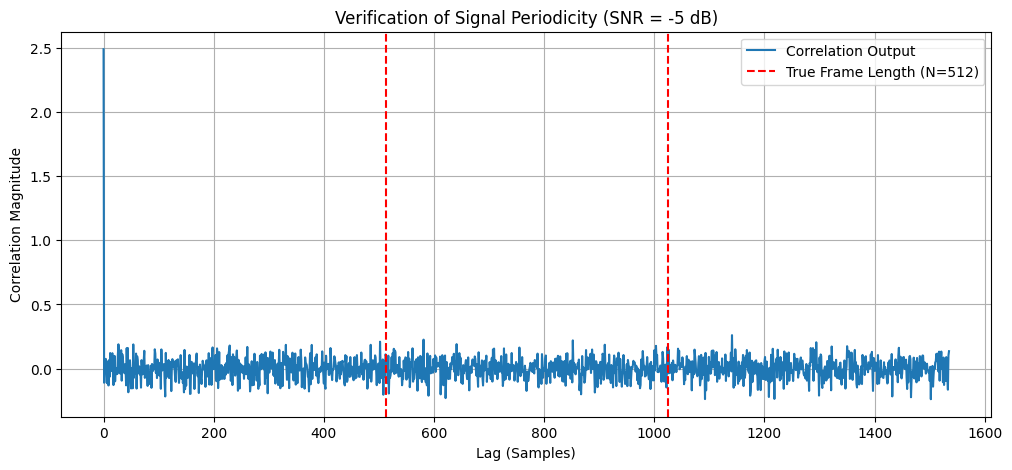

In [3]:
def verify_periodicity(signal, max_lag):
    # Take a reference window (w0) from the start of the signal
    w_size = 2 * N # Using a window larger than N to capture the SW
    w0 = signal[:w_size]
    
    correlations = []
    lags = np.arange(0, max_lag)
    
    for lag in lags:
        # Slide window wm
        wm = signal[lag : lag + w_size]
        # Calculate correlation
        corr = np.sum(w0 * wm) / w_size
        correlations.append(corr)
    
    return lags, correlations

# Run verification
lags, corr_values = verify_periodicity(rx_signal, 3 * N)

plt.figure(figsize=(12, 5))
plt.plot(lags, corr_values, label='Correlation Output')
plt.axvline(x=N, color='r', linestyle='--', label=f'True Frame Length (N={N})')
plt.axvline(x=2*N, color='r', linestyle='--')
plt.title(f"Verification of Signal Periodicity (SNR = {SNR_dB} dB)")
plt.xlabel("Lag (Samples)")
plt.ylabel("Correlation Magnitude")
plt.legend()
plt.grid(True)
plt.show()

4. Why this data is "Paper-Ready"

When presenting this to your professor, highlight these points:

    Stationarity of SW: The Sync Word remains identical across all M frames, while the payload is purely random. This satisfies the E[Data]=0 assumption used in the Periodic Averaging function.

    BPSK Mapping: We used ±1 values, which allows the use of Linear Correlation and Sign Functions (sgn) as described in the paper's math.

    Timing Offset (δ): The signal doesn't start at index 0. This forces the implementation to actually "search" for the frame start, making the simulation realistic for blind recognition.